# Agentic AI — Assignment Alpha
## Q3: Rain Prediction for Drone Parcel Delivery

The learning agent predicts whether it will rain from **Wind** and **Humidity**.  
If rain is predicted, the drone should **not deliver** the parcel; otherwise, it may deliver.

### Given training data

| # | Wind | Humidity | Rain |
|---:|---|---|---|
| 1 | Weak | High | Yes |
| 2 | Strong | High | Yes |
| 3 | Weak | Low | No |
| 4 | Weak | Low | Yes |
| 5 | Strong | Low | No |

This notebook implements:

1. Naive Bayes with **Laplace smoothing**
2. Entropy and Information Gain / Decision Tree
3. Logistic Regression
4. Comparison of the three learning methods

> **Important observation:** rows 3 and 4 have exactly the same input features `(Weak, Low)` but opposite labels. Therefore, using only Wind and Humidity, no deterministic classifier can classify all five training rows correctly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log2

from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

df = pd.DataFrame({
    "Wind": ["Weak", "Strong", "Weak", "Weak", "Strong"],
    "Humidity": ["High", "High", "Low", "Low", "Low"],
    "Rain": ["Yes", "Yes", "No", "Yes", "No"]
})
df.index = range(1, len(df) + 1)

print("Training dataset:")
display(df)

Training dataset:


,Wind,Humidity,Rain
1,Weak,High,Yes
2,Strong,High,Yes
3,Weak,Low,No
4,Weak,Low,Yes
5,Strong,Low,No


---
# Part 1 — Naive Bayes with Laplace Smoothing

For class \(C\in\{Yes,No\}\),

\[
P(C\mid Wind,Humidity)\propto
P(C)\,P(Wind\mid C)\,P(Humidity\mid C)
\]

Laplace smoothing with \(\alpha=1\) is:

\[
P(x=v\mid C)=
\frac{count(x=v,C)+1}{count(C)+k}
\]

where \(k=2\) because both Wind and Humidity have two possible values.

In [ ]:
# ----- Step 1: Priors -----
n = len(df)
yes_count = (df["Rain"] == "Yes").sum()
no_count = (df["Rain"] == "No").sum()

p_yes = yes_count / n
p_no = no_count / n

print(f"P(Yes) = {yes_count}/{n} = {p_yes:.3f}")
print(f"P(No)  = {no_count}/{n} = {p_no:.3f}")

P(Yes) = 3/5 = 0.600
P(No)  = 2/5 = 0.400


In [ ]:
# ----- Step 2: Laplace-smoothed conditional probabilities -----
alpha = 1
k = 2

def laplace_prob(feature, value, cls):
    cls_rows = df[df["Rain"] == cls]
    count = (cls_rows[feature] == value).sum()
    return (count + alpha) / (len(cls_rows) + alpha * k)

conditionals = pd.DataFrame({
    "P(Weak | class)": [
        laplace_prob("Wind", "Weak", "No"),
        laplace_prob("Wind", "Weak", "Yes")
    ],
    "P(Strong | class)": [
        laplace_prob("Wind", "Strong", "No"),
        laplace_prob("Wind", "Strong", "Yes")
    ],
    "P(Low | class)": [
        laplace_prob("Humidity", "Low", "No"),
        laplace_prob("Humidity", "Low", "Yes")
    ],
    "P(High | class)": [
        laplace_prob("Humidity", "High", "No"),
        laplace_prob("Humidity", "High", "Yes")
    ]
}, index=["No", "Yes"])

display(conditionals.round(3))

,P(Weak | class),P(Strong | class),P(Low | class),P(High | class)
No,0.5,0.5,0.75,0.25
Yes,0.6,0.4,0.40,0.60


In [ ]:
# ----- Step 3: Predict all possible Wind/Humidity combinations -----
combinations = pd.DataFrame([
    ("Weak", "High"),
    ("Strong", "High"),
    ("Weak", "Low"),
    ("Strong", "Low")
], columns=["Wind", "Humidity"])

rows = []
for _, r in combinations.iterrows():
    w, h = r["Wind"], r["Humidity"]

    yes_score = p_yes * laplace_prob("Wind", w, "Yes") * laplace_prob("Humidity", h, "Yes")
    no_score  = p_no  * laplace_prob("Wind", w, "No")  * laplace_prob("Humidity", h, "No")

    total = yes_score + no_score
    post_yes = yes_score / total
    post_no = no_score / total

    pred = "Yes" if post_yes > post_no else "No"
    action = "Do NOT deliver" if pred == "Yes" else "Deliver"

    rows.append([w, h, yes_score, no_score, post_yes, post_no, pred, action])

nb_results = pd.DataFrame(rows, columns=[
    "Wind", "Humidity", "Yes score", "No score",
    "P(Yes)", "P(No)", "Predicted Rain", "Drone Action"
])

display(nb_results.round(3))

,Wind,Humidity,Yes score,No score,P(Yes),P(No),Predicted Rain,Drone Action
0,Weak,High,0.216,0.05,0.812,0.188,Yes,Do NOT deliver
1,Strong,High,0.144,0.05,0.742,0.258,Yes,Do NOT deliver
2,Weak,Low,0.144,0.15,0.490,0.510,No,Deliver
3,Strong,Low,0.096,0.15,0.390,0.610,No,Deliver


In [ ]:
# ----- Step 4: Naive Bayes training accuracy -----
def nb_predict_row(row):
    w, h = row["Wind"], row["Humidity"]
    yes_score = p_yes * laplace_prob("Wind", w, "Yes") * laplace_prob("Humidity", h, "Yes")
    no_score  = p_no  * laplace_prob("Wind", w, "No")  * laplace_prob("Humidity", h, "No")
    return "Yes" if yes_score > no_score else "No"

nb_train_pred = df.apply(nb_predict_row, axis=1)
nb_accuracy = (nb_train_pred == df["Rain"]).mean()

print("Training predictions:", list(nb_train_pred))
print(f"Naive Bayes training accuracy = {nb_accuracy:.0%}")

Training predictions: ['Yes', 'Yes', 'No', 'No', 'No']
Naive Bayes training accuracy = 80%


---
# Part 2 — Entropy and Information Gain

Entropy:

\[
H(S)=-\sum_i p_i\log_2 p_i
\]

Information Gain:

\[
IG(S,A)=H(S)-\sum_v\frac{|S_v|}{|S|}H(S_v)
\]

In [ ]:
def entropy_from_labels(labels):
    counts = pd.Series(labels).value_counts()
    total = counts.sum()
    H = 0.0
    for c in counts:
        p = c / total
        H -= p * log2(p)
    return H

H_S = entropy_from_labels(df["Rain"])
print(f"H(S) = {H_S:.4f}")

H(S) = 0.9710


In [ ]:
def information_gain(data, feature, target="Rain"):
    parent_entropy = entropy_from_labels(data[target])
    weighted_entropy = 0.0

    details = []
    for value, subset in data.groupby(feature):
        H = entropy_from_labels(subset[target])
        weight = len(subset) / len(data)
        weighted_entropy += weight * H
        details.append((value, len(subset), H, weight))

    return parent_entropy - weighted_entropy, weighted_entropy, details

ig_wind, we_wind, wind_details = information_gain(df, "Wind")
ig_hum, we_hum, hum_details = information_gain(df, "Humidity")

print("Wind split:")
for value, size, H, weight in wind_details:
    print(f"  {value}: n={size}, entropy={H:.4f}, weight={weight:.3f}")
print(f"Weighted entropy = {we_wind:.4f}")
print(f"IG(Wind) = {ig_wind:.4f}")

print("\nHumidity split:")
for value, size, H, weight in hum_details:
    print(f"  {value}: n={size}, entropy={H:.4f}, weight={weight:.3f}")
print(f"Weighted entropy = {we_hum:.4f}")
print(f"IG(Humidity) = {ig_hum:.4f}")

print("\nBest root feature =", "Humidity" if ig_hum > ig_wind else "Wind")

Wind split:
  Strong: n=2, entropy=1.0000, weight=0.400
  Weak: n=3, entropy=0.9183, weight=0.600
Weighted entropy = 0.9510
IG(Wind) = 0.0200

Humidity split:
  High: n=2, entropy=0.0000, weight=0.400
  Low: n=3, entropy=0.9183, weight=0.600
Weighted entropy = 0.5510
IG(Humidity) = 0.4200

Best root feature = Humidity


In [ ]:
# ----- Low-Humidity branch: calculate IG of Wind -----
low_df = df[df["Humidity"] == "Low"].copy()
H_low = entropy_from_labels(low_df["Rain"])
ig_low_wind, we_low_wind, low_details = information_gain(low_df, "Wind")

print("Low-humidity subset:")
display(low_df)

print(f"H(Low humidity subset) = {H_low:.4f}")
for value, size, H, weight in low_details:
    print(f"  Wind={value}: n={size}, entropy={H:.4f}, weight={weight:.3f}")
print(f"Weighted entropy after splitting Low branch on Wind = {we_low_wind:.4f}")
print(f"IG(Wind | Low humidity) = {ig_low_wind:.4f}")

Low-humidity subset:


,Wind,Humidity,Rain
3,Weak,Low,No
4,Weak,Low,Yes
5,Strong,Low,No


H(Low humidity subset) = 0.9183
  Wind=Strong: n=1, entropy=0.0000, weight=0.333
  Wind=Weak: n=2, entropy=1.0000, weight=0.667
Weighted entropy after splitting Low branch on Wind = 0.6667
IG(Wind | Low humidity) = 0.2516


### Decision rule obtained from entropy / information gain

- **Humidity = High** → Rain = **Yes**
- **Humidity = Low, Wind = Strong** → Rain = **No**
- **Humidity = Low, Wind = Weak** → one Yes and one No are identical in the data, so the branch is a tie.  
  Using the parent majority class gives **No**.

|--- Humidity_High <= 0.50
|   |--- Wind_Strong <= 0.50
|   |   |--- class: 0
|   |--- Wind_Strong >  0.50
|   |   |--- class: 0
|--- Humidity_High >  0.50
|   |--- class: 1

Decision Tree training accuracy = 80%


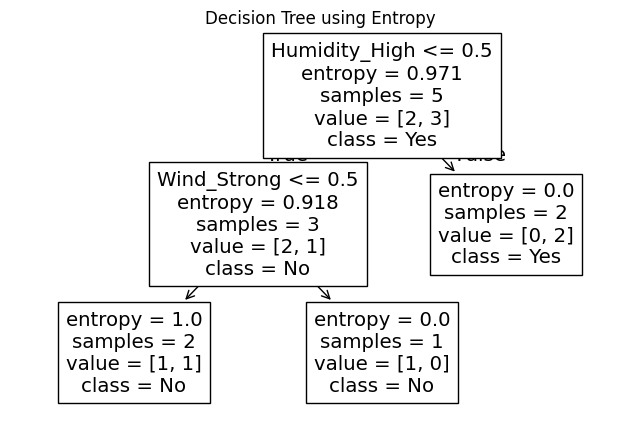

In [ ]:
# Encode for scikit-learn:
# Wind: Weak=0, Strong=1
# Humidity: Low=0, High=1
X = np.column_stack([
    (df["Wind"] == "Strong").astype(int),
    (df["Humidity"] == "High").astype(int)
])
y = (df["Rain"] == "Yes").astype(int).to_numpy()

tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
tree.fit(X, y)

print(export_text(tree, feature_names=["Wind_Strong", "Humidity_High"]))
print(f"Decision Tree training accuracy = {tree.score(X, y):.0%}")

plt.figure(figsize=(8, 5))
plot_tree(
    tree,
    feature_names=["Wind_Strong", "Humidity_High"],
    class_names=["No", "Yes"],
    filled=False
)
plt.title("Decision Tree using Entropy")
plt.show()

---
# Part 3 — Logistic Regression

Encoding:

\[
Weak=0,\ Strong=1,\quad Low=0,\ High=1,\quad No=0,\ Yes=1
\]

Model:

\[
P(Rain=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}
\]

\[
z=b+w_1(Wind)+w_2(Humidity)
\]

We first show the **first gradient-descent update manually in code**, then train the model for many iterations.

In [ ]:
X_table = pd.DataFrame({
    "Wind_Strong": (df["Wind"] == "Strong").astype(int),
    "Humidity_High": (df["Humidity"] == "High").astype(int),
    "Rain_Yes": y
})
display(X_table)

,Wind_Strong,Humidity_High,Rain_Yes
1,0,1,1
2,1,1,1
3,0,0,0
4,0,0,1
5,1,0,0


In [ ]:
# ----- First gradient-descent iteration -----
X_np = X.astype(float)
y_np = y.astype(float)
m = len(y_np)

w = np.zeros(2)
b = 0.0
learning_rate = 0.5

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = X_np @ w + b
p = sigmoid(z)

error = p - y_np
db = error.mean()
dw = (X_np.T @ error) / m

print("Initial probabilities =", p)
print(f"db = {db:.3f}")
print(f"dw_wind = {dw[0]:.3f}")
print(f"dw_humidity = {dw[1]:.3f}")

b = b - learning_rate * db
w = w - learning_rate * dw

print("\nAfter first update:")
print(f"b = {b:.3f}")
print(f"w_wind = {w[0]:.3f}")
print(f"w_humidity = {w[1]:.3f}")

Initial probabilities = [0.5 0.5 0.5 0.5 0.5]
db = -0.100
dw_wind = 0.000
dw_humidity = -0.200

After first update:
b = 0.050
w_wind = 0.000
w_humidity = 0.100


In [ ]:
# ----- Continue gradient descent -----
# Restart from zero so the complete run is reproducible.
w = np.zeros(2)
b = 0.0
learning_rate = 0.5
iterations = 1000

loss_history = []

for _ in range(iterations):
    z = X_np @ w + b
    p = sigmoid(z)

    eps = 1e-12
    loss = -np.mean(y_np*np.log(p + eps) + (1-y_np)*np.log(1-p + eps))
    loss_history.append(loss)

    error = p - y_np
    db = error.mean()
    dw = (X_np.T @ error) / m

    b -= learning_rate * db
    w -= learning_rate * dw

print(f"After {iterations} iterations:")
print(f"b = {b:.4f}")
print(f"w_wind = {w[0]:.4f}")
print(f"w_humidity = {w[1]:.4f}")
print(f"Final log-loss = {loss_history[-1]:.4f}")

After 1000 iterations:
b = -0.0193
w_wind = -3.4995
w_humidity = 7.4756
Final log-loss = 0.2870


In [ ]:
# Predict the four possible conditions
X_combo = np.column_stack([
    (combinations["Wind"] == "Strong").astype(int),
    (combinations["Humidity"] == "High").astype(int)
]).astype(float)

prob_yes = sigmoid(X_combo @ w + b)
pred_lr = (prob_yes >= 0.5).astype(int)

lr_results = combinations.copy()
lr_results["P(Yes)"] = prob_yes
lr_results["Predicted Rain"] = np.where(pred_lr == 1, "Yes", "No")
lr_results["Drone Action"] = np.where(pred_lr == 1, "Do NOT deliver", "Deliver")

display(lr_results.round(3))

train_prob = sigmoid(X_np @ w + b)
train_pred = (train_prob >= 0.5).astype(int)
lr_accuracy = accuracy_score(y, train_pred)
print(f"Logistic Regression training accuracy = {lr_accuracy:.0%}")

,Wind,Humidity,P(Yes),Predicted Rain,Drone Action
0,Weak,High,0.999,Yes,Do NOT deliver
1,Strong,High,0.981,Yes,Do NOT deliver
2,Weak,Low,0.495,No,Deliver
3,Strong,Low,0.029,No,Deliver


Logistic Regression training accuracy = 80%


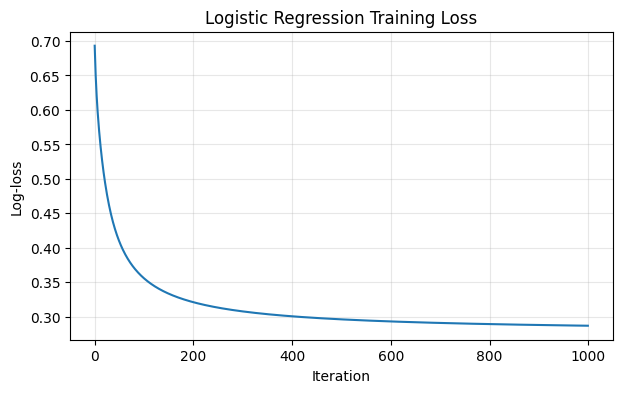

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Log-loss")
plt.title("Logistic Regression Training Loss")
plt.grid(alpha=0.3)
plt.show()

> **Note:** The dataset is extremely small, and High Humidity perfectly separates the two observed high-humidity examples from the No class. Therefore, unregularized logistic-regression coefficients can continue to grow with more iterations. The important interpretation is that **Humidity receives a strong positive weight** and Wind a negative weight.

---
# Part 4 — Comparison of the Three Algorithms

In [ ]:
# Helper predictions for all training rows
tree_pred = np.where(tree.predict(X) == 1, "Yes", "No")
lr_train_pred_labels = np.where(train_pred == 1, "Yes", "No")

comparison = pd.DataFrame({
    "Algorithm": ["Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Training Accuracy": [
        f"{nb_accuracy:.0%}",
        f"{tree.score(X, y):.0%}",
        f"{lr_accuracy:.0%}"
    ],
    "Main Behaviour": [
        "Uses class and conditional probabilities with Laplace smoothing",
        "Chooses Humidity as the root because it has the highest information gain",
        "Learns a strong positive weight for High Humidity"
    ],
    "Main Limitation Here": [
        "Assumes conditional independence of features",
        "Weak+Low is a tie because identical inputs have opposite labels",
        "Very small / partly separable dataset makes coefficients unstable"
    ]
})
display(comparison)

,Algorithm,Training Accuracy,Main Behaviour,Main Limitation Here
0,Naive Bayes,80%,Uses class and conditional probabilities with ...,Assumes conditional independence of features
1,Decision Tree,80%,Chooses Humidity as the root because it has th...,Weak+Low is a tie because identical inputs hav...
2,Logistic Regression,80%,Learns a strong positive weight for High Humidity,Very small / partly separable dataset makes co...


## Final conclusion

All three methods learn essentially the same important pattern:

\[
\boxed{\text{High Humidity strongly indicates Rain}}
\]

The maximum deterministic training accuracy is **80%** because the dataset contains two identical `(Weak, Low)` inputs with opposite Rain labels.